In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [55]:
# Set publication-quality plot styling
sns.set_theme(style="whitegrid", context="paper", font="Arial")
sns.despine()
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 15, 
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.title_fontsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.6
})

<Figure size 640x480 with 0 Axes>

In [56]:
all_epidemics_ds = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
all_epidemics_ds = all_epidemics_ds.rename(columns={'severity_smu': 'severity'}) # Name change simplifies code later

In [57]:
all_epidemics_ds.loc[all_epidemics_ds['disease'] == 'hiv/aids', 'duration'] = 46

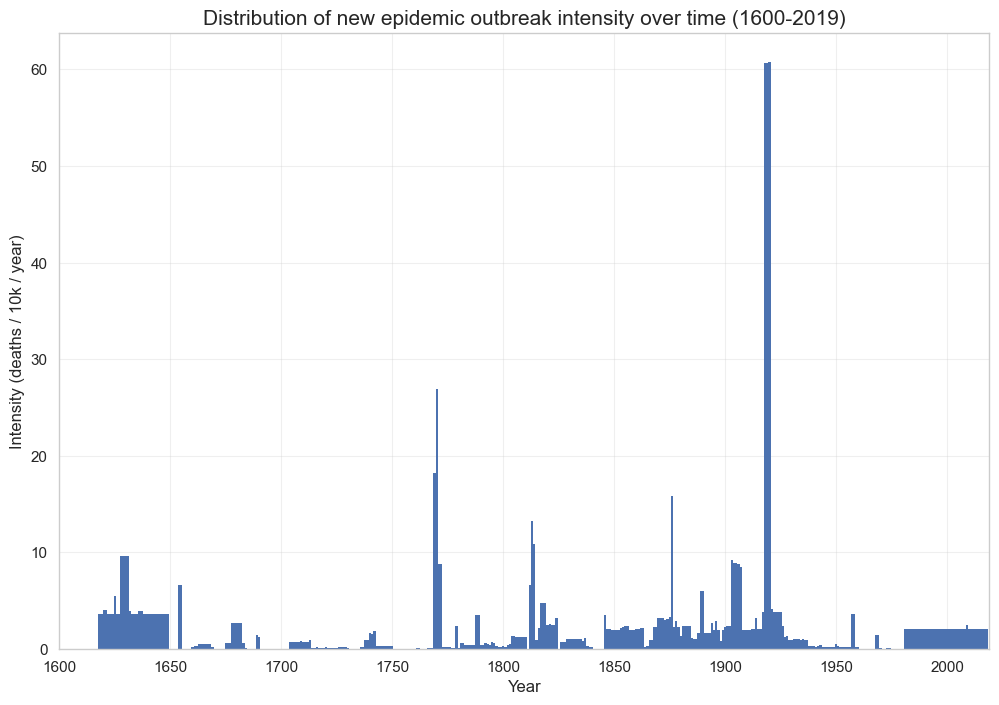

In [68]:
# Remove pandemics with negative severity
valid_epidemics = all_epidemics_ds[all_epidemics_ds['severity'] >= 0]
valid_epidemics = valid_epidemics[valid_epidemics['year_start'] >= 1600]

# Create a vector of years from 1600 to 2019
years = pd.Series(range(1600, 2019))
annual_severity = pd.Series(0.0, index=years)

# Distribute severity across years for each pandemic
for _, pandemic in valid_epidemics.iterrows():
    start_year = pandemic['year_start']
    end_year = pandemic['year_end'] 
    duration = pandemic['duration']
    severity_per_year = pandemic['severity'] / duration
    
    # Add the distributed severity to each year the pandemic was active
    annual_severity.loc[start_year:end_year] += severity_per_year

# Create the bar plot
plt.figure(figsize=(12, 8))
plt.bar(annual_severity.index, annual_severity.values, width=1, edgecolor='none')
plt.xlabel('Year')
plt.ylabel('Intensity (deaths / 10k / year)')
plt.title('Distribution of new epidemic outbreak intensity over time (1600-2019)')
plt.xlim([1600, 2019])
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\squaade\AppData\Local\Temp\ipykernel_38900\351338881.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(lorenz_y, lorenz_x)


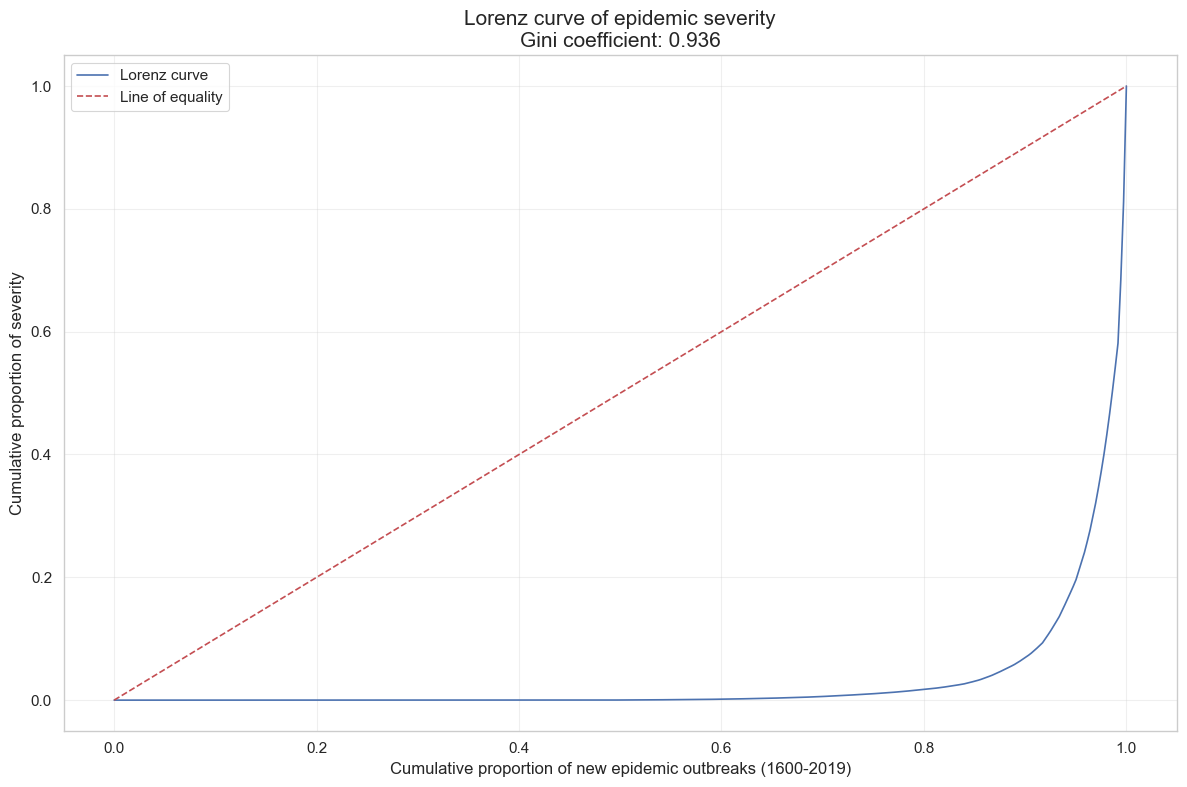

In [67]:
# Calculate Lorenz curve data for valid epidemics
total_severity = valid_epidemics['severity'].sum()
sorted_severity = valid_epidemics['severity'].sort_values()
cumulative_severity = sorted_severity.cumsum()
lorenz_y = cumulative_severity / total_severity
lorenz_x = np.linspace(0, 1, len(lorenz_y))

# Create Lorenz curve plot
plt.figure(figsize=(12, 8))
plt.plot(lorenz_x, lorenz_y, 'b-', label='Lorenz curve')
plt.plot([0, 1], [0, 1], 'r--', label='Line of equality') 

# Calculate Gini coefficient
gini = 1 - 2 * np.trapz(lorenz_y, lorenz_x)

# Add labels and title
plt.xlabel('Cumulative proportion of new epidemic outbreaks (1600-2019)')
plt.ylabel('Cumulative proportion of severity')
plt.title(f'Lorenz curve of epidemic severity\nGini coefficient: {gini:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

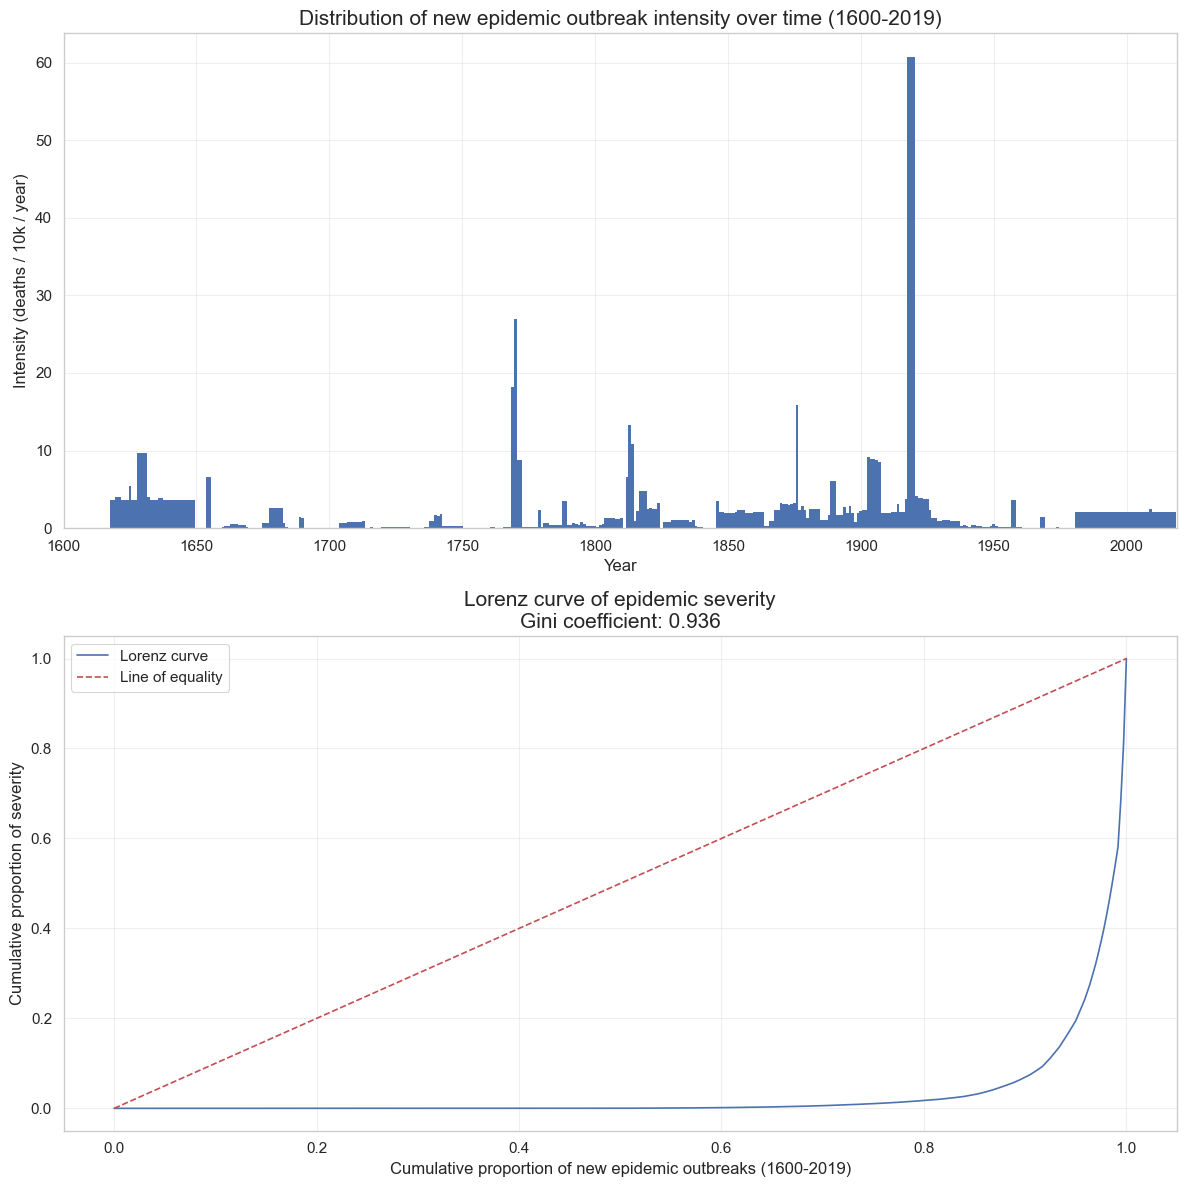

In [77]:
# Create figure with two subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Top subplot - Annual intensity bars
ax1.bar(annual_severity.index, annual_severity.values, width=1, edgecolor='none')
ax1.set_xlabel('Year')
ax1.set_ylabel('Intensity (deaths / 10k / year)')
ax1.set_title('Distribution of new epidemic outbreak intensity over time (1600-2019)')
ax1.set_xlim([1600, 2019])
ax1.grid(True, alpha=0.3)

# Bottom subplot - Lorenz curve
ax2.plot(lorenz_x, lorenz_y, 'b-', label='Lorenz curve')
ax2.plot([0, 1], [0, 1], 'r--', label='Line of equality')
ax2.set_xlabel('Cumulative proportion of new epidemic outbreaks (1600-2019)')
ax2.set_ylabel('Cumulative proportion of severity') 
ax2.set_title(f'Lorenz curve of epidemic severity\nGini coefficient: {gini:.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Adjust spacing between subplots
plt.tight_layout()
plt.show()
